# Everything Plus — Segmentação de Usuários e Análise de Compras

## Objetivo

Segmentar usuários com base em seus perfis de consumo, analisando o histórico de compras por tipo de produto, com o intuito de gerar insights para personalização de ofertas e estratégias de marketing.

## Pré-Processamento dos dados

In [2]:
# importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [3]:
# carregar os dados
df = pd.read_csv('/datasets/ecommerce_dataset_us.csv', sep='\t')
display(df.head())
df.info()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,11/29/2018 08:26,2.55,17850.0
1,536365,71053,WHITE METAL LANTERN,6,11/29/2018 08:26,3.39,17850.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,11/29/2018 08:26,2.75,17850.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,11/29/2018 08:26,3.39,17850.0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,11/29/2018 08:26,3.39,17850.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 28.9+ MB


In [4]:
# tratar valores ausentes
df = df.dropna(subset=['CustomerID', 'Description'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 406829 entries, 0 to 541908
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 24.8+ MB


In [5]:
# tratar tipos dos dados
# Converter datas
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Converter colunas categóricas
df['InvoiceNo'] = df['InvoiceNo'].astype('category')
df['StockCode'] = df['StockCode'].astype('category')
df['Description'] = df['Description'].astype('category')
df['CustomerID'] = df['CustomerID'].astype(int).astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 406829 entries, 0 to 541908
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  category      
 1   StockCode    406829 non-null  category      
 2   Description  406829 non-null  category      
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  category      
dtypes: category(4), datetime64[ns](1), float64(1), int64(1)
memory usage: 16.7 MB


In [6]:
# tratar valores invalidos
# Remove cancelamentos
df = df[~df['InvoiceNo'].str.startswith('C')]

# Remove preços inválidos
df = df[(df['UnitPrice'] > 0)]

df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 397884 entries, 0 to 541908
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  category      
 1   StockCode    397884 non-null  category      
 2   Description  397884 non-null  category      
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  category      
dtypes: category(4), datetime64[ns](1), float64(1), int64(1)
memory usage: 16.3 MB


In [7]:
# Cria coluna de gasto total por item
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

## Análise exploratória de dados

### Analisar o histórico de compras de cada usuário:

#### Quantas compras diferentes o cliente fez

In [8]:
# Frequência de compras
num_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()
print(num_orders.value_counts().head())

1    1493
2     835
3     508
4     388
5     242
Name: InvoiceNo, dtype: int64


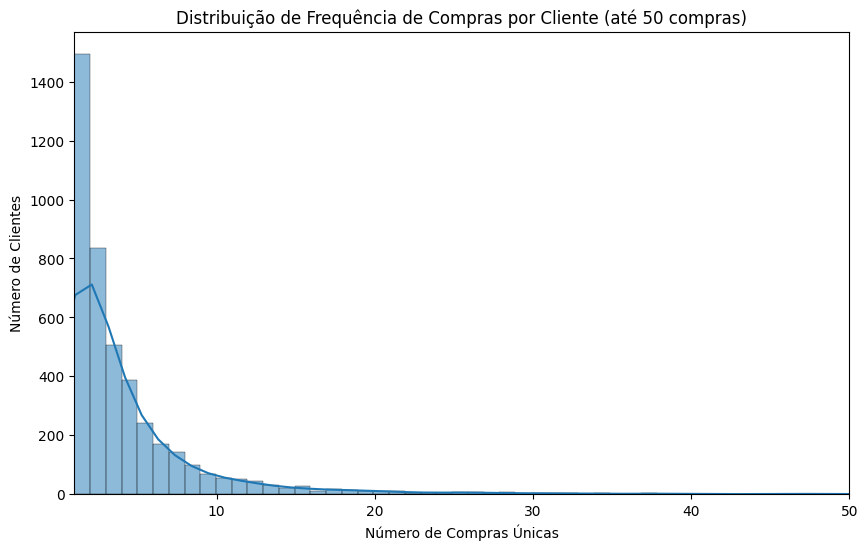

In [9]:
# plotar um grafico para visualização
plt.figure(figsize=(10, 6))
sns.histplot(num_orders, bins=210, kde=True)
plt.xlim(1, 50)
plt.title('Distribuição de Frequência de Compras por Cliente (até 50 compras)')
plt.xlabel('Número de Compras Únicas')
plt.ylabel('Número de Clientes')
plt.show()

- A distribuição de frequencia de compras concentra-se perto de 1 por cliente e diminui exponencialmente.

#### Quantos produtos distintos ele comprou

In [10]:
# Diversidade de produtos
product_diversity = df.groupby('CustomerID')['StockCode'].nunique()
print(product_diversity.value_counts().head())

1     91
11    86
8     82
10    79
14    77
Name: StockCode, dtype: int64


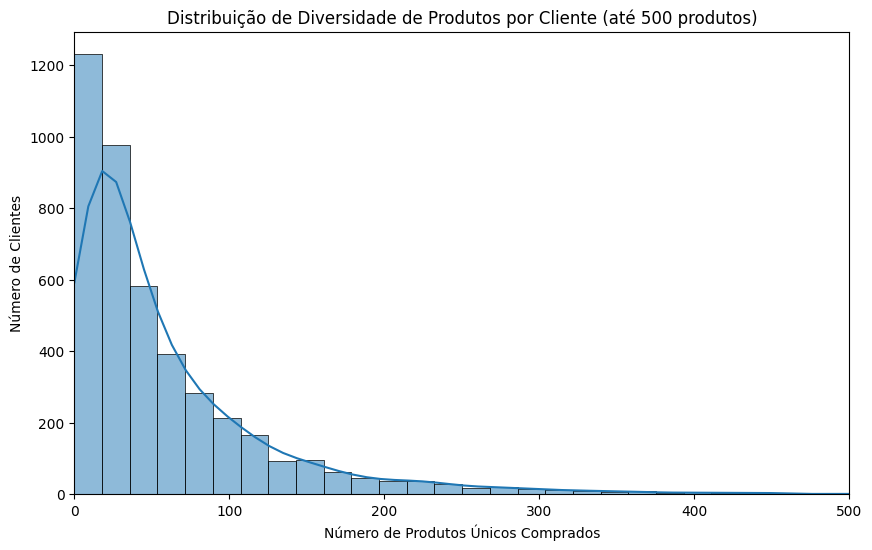

In [11]:
# plotar um grafico para visualização
plt.figure(figsize=(10, 6))
sns.histplot(product_diversity, bins=100, kde=True)
plt.xlim(0, 500)  
plt.title('Distribuição de Diversidade de Produtos por Cliente (até 500 produtos)')
plt.xlabel('Número de Produtos Únicos Comprados')
plt.ylabel('Número de Clientes')
plt.show()

- A distribuição de diversidade de produtos por cliente, de forma análoga, tambem concentra-se perto de 1 por cliente e diminui exponencialmente.

#### Valor médio gasto por compra

In [12]:
# Total gasto por cliente
total_spent = df.groupby('CustomerID')['TotalPrice'].sum()

# Ticket médio
atp = total_spent/ num_orders

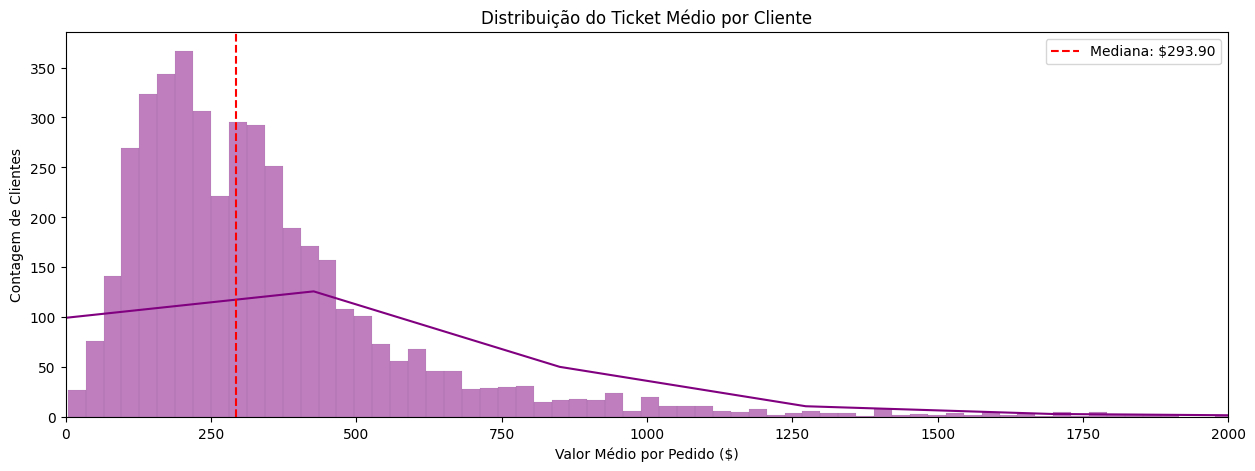

In [13]:
# plotar um grafico para visualização
plt.figure(figsize=(15, 5))
sns.histplot(atp.dropna(), kde=True, color='purple')
plt.xlim(0, 2000) 
plt.title('Distribuição do Ticket Médio por Cliente')
plt.xlabel('Valor Médio por Pedido ($)')
plt.ylabel('Contagem de Clientes')
plt.axvline(atp.median(), color='red', linestyle='--', label=f'Mediana: ${atp.median():.2f}')
plt.legend()
plt.show()

- Podemos ver uma clara distribuição do ticket médio ao redor da mediana de $293.90.

#### Dias médios entre compras

In [14]:
# Remover duplicatas por cliente e pedido, mantendo apenas uma data por compra
df_unique = df[['CustomerID', 'InvoiceDate', 'InvoiceNo']].drop_duplicates()
df_unique = df_unique.sort_values(by=['CustomerID', 'InvoiceDate'])

# Calcular diferença entre datas de compras consecutivas por cliente
df_unique['diff_days'] = df_unique.groupby('CustomerID')['InvoiceDate'].diff().dt.days

# Calcular média dos dias entre compras (ignorando NaNs da primeira compra)
avg_days_between = df_unique.groupby('CustomerID')['diff_days'].mean()

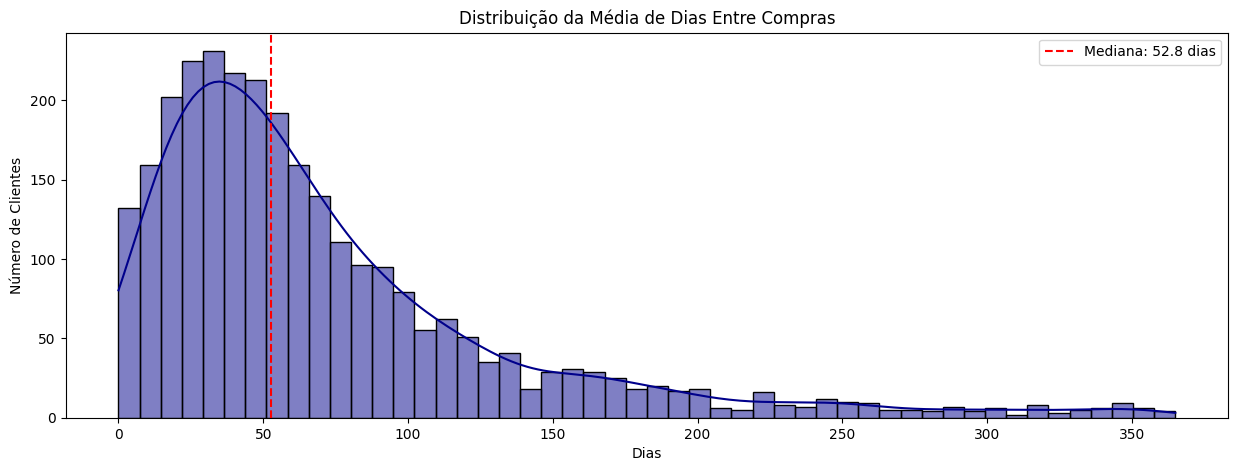

In [15]:
# plotar um grafico para visualização
plt.figure(figsize=(15, 5))
sns.histplot(avg_days_between.dropna(), bins=50, kde=True, color='darkblue')
plt.title('Distribuição da Média de Dias Entre Compras')
plt.xlabel('Dias')
plt.ylabel('Número de Clientes')
plt.axvline(avg_days_between.median(), color='red', linestyle='--', 
            label=f'Mediana: {avg_days_between.median():.1f} dias')
plt.legend()
plt.show()

- A média de dias entre as compras dos usuários fica ao redor de 52 dias, com uma calda a direita na distriuição.

### Representar o perfil de cada usuário como um vetor com essas características

In [16]:
user_profile = pd.concat([
    num_orders.rename('purchase_frequency'),
    product_diversity.rename('product_diversity'),
    atp.rename('avg_ticket'),
    avg_days_between.rename('avg_days_between_purchases')
], axis=1).fillna(0)
user_profile

,purchase_frequency,product_diversity,avg_ticket,avg_days_between_purchases
CustomerID,,,,
12346,1,1,77183.600000,0.000000
12347,7,103,615.714286,60.333333
12348,4,22,449.310000,94.000000
12349,1,73,1757.550000,0.000000
12350,1,17,334.400000,0.000000
...,...,...,...,...
18280,1,10,180.600000,0.000000
18281,1,7,80.820000,0.000000
18282,2,12,89.025000,118.000000


## Clusterização e análise dos clusters

### Normalizar os dados e limpar outliers

In [17]:
# Normalizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(user_profile)

# Calcula o z-score dos dados normalizados
z_scores = np.abs(zscore(X_scaled))

# Define um limiar (threshold)
threshold = 3

# Mantém apenas os dados cujos z-scores estão abaixo do threshold em todas as colunas
mask = (z_scores < threshold).all(axis=1)

# Filtra os dados
X_clean = X_scaled[mask]
user_profile_clean = user_profile[mask]

### Definir o numero ideal de clusters

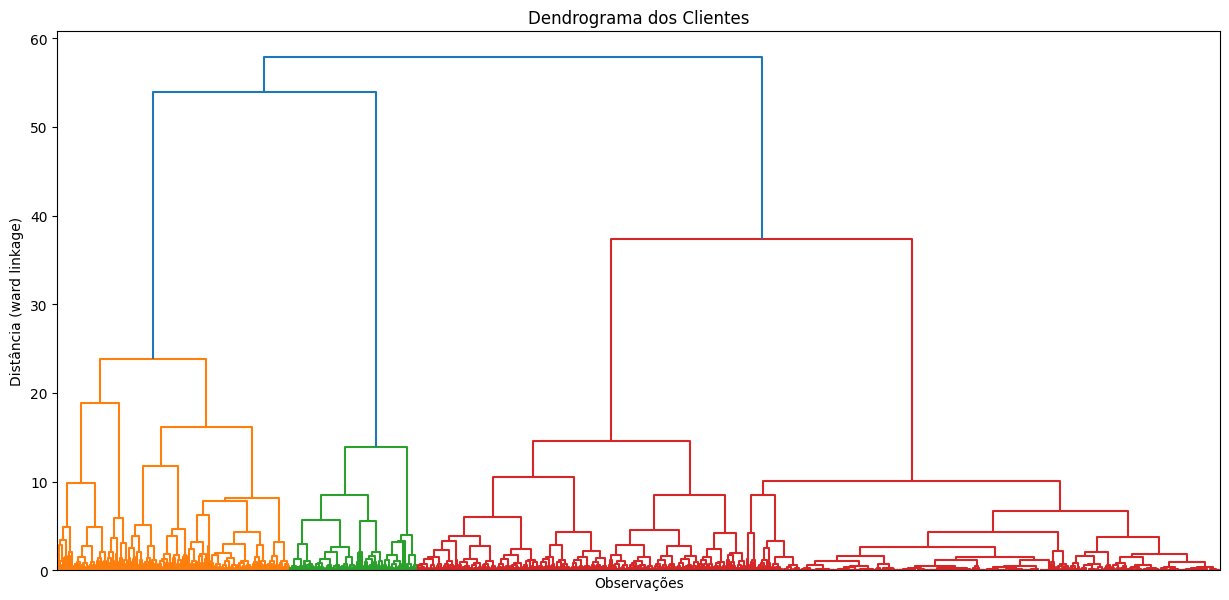

In [18]:
# Construir a matriz de linkage com o método 'ward'
linked = linkage(X_clean, method='ward')

# Visualizar o dendrograma
plt.figure(figsize=(15, 7))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False,
           no_labels=True)

plt.title('Dendrograma dos Clientes')
plt.xlabel('Observações')
plt.ylabel('Distância (ward linkage)')
plt.show()


In [19]:
# Analisando diferentes quantidades de clusters
range_n_clusters = range(2, 11)
scores = []

for n_clusters in range_n_clusters:
    clusterer = AgglomerativeClustering(n_clusters=n_clusters)
    cluster_labels = clusterer.fit_predict(X_clean)
    score = silhouette_score(X_clean, cluster_labels)
    scores.append(score)
    print(f'Clusters: {n_clusters}, Silhouette Score: {score:.4f}')

Clusters: 2, Silhouette Score: 0.4102
Clusters: 3, Silhouette Score: 0.4590
Clusters: 4, Silhouette Score: 0.4223
Clusters: 5, Silhouette Score: 0.4310
Clusters: 6, Silhouette Score: 0.4364
Clusters: 7, Silhouette Score: 0.4331
Clusters: 8, Silhouette Score: 0.3755
Clusters: 9, Silhouette Score: 0.3700
Clusters: 10, Silhouette Score: 0.3728


### Analisar o perfil de cada cluster com base nas métricas

In [20]:
# Treinamento do modelo KMeans
kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
clusters = kmeans.fit_predict(X_clean)

# Adiciona os clusters ao DataFrame dos vetores
user_profile_clean = user_profile_clean.copy()
user_profile_clean['cluster'] = clusters

# Calcula o valor médio por cluster
cluster_means = user_profile_clean.groupby('cluster').mean(numeric_only=True).round(2)
cluster_means

,purchase_frequency,product_diversity,avg_ticket,avg_days_between_purchases
cluster,,,,
0,4.60,55.11,349.54,59.10
1,9.90,164.08,497.13,37.29
2,2.49,45.72,345.32,149.51
3,1.28,22.23,333.86,2.87


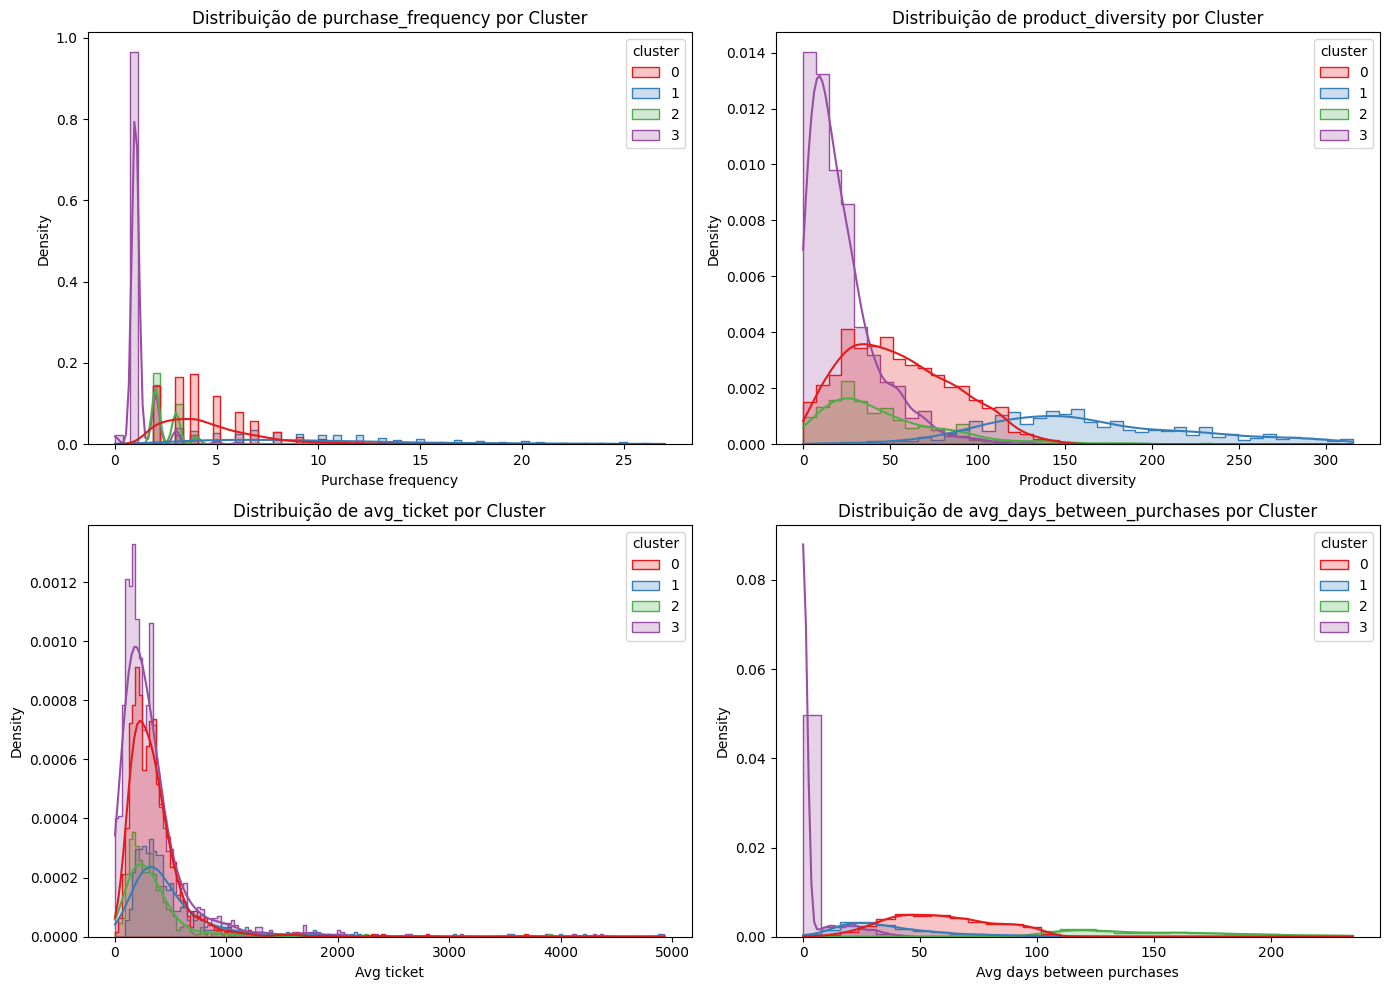

In [21]:
# Lista com os nomes das features
features = ['purchase_frequency', 'product_diversity', 'avg_ticket', 'avg_days_between_purchases']

# Número de variáveis
n = len(features)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Deixar os eixos planos para iterar
axes = axes.flatten()

# Plotar cada feature com a coloração por cluster
for i, col in enumerate(features):
    sns.histplot(data=user_profile_clean, x=col, hue='cluster', kde=True, element='step', stat='density', ax=axes[i], palette='Set1')
    axes[i].set_title(f'Distribuição de {col} por Cluster')
    axes[i].set_xlabel(col.replace('_', ' ').capitalize())

plt.tight_layout()
plt.show()

**Conclusão:**
- **Cluster 3** são clientes inativos ou de compra única → foco em reativação.

- **Cluster 2** são clientes que compram pouco e com intervalos longos → merecem retenção ativa. 

- **Cluster 1** tem alto ticket médio e boa frequência de compras → manter com ações leves de fidelização.

- **Cluster 0** são clientes moderados e estáveis → potencial para aumentar engajamento.

### Analisar os produtos comprados por cada cluster

In [22]:
# Juntar cluster às transações
df_clustered = df.merge(user_profile_clean, on='CustomerID')

# Contar compras por produto dentro de cada cluster
top_products_per_cluster = (
    df_clustered.groupby(['cluster', 'Description'])
    .size()
    .reset_index(name='purchase_count')
)

# Pegar os top 5 produtos por cluster
top5_products_per_cluster = (
    top_products_per_cluster.sort_values(['cluster', 'purchase_count'], ascending=[True, False])
    .groupby('cluster')
    .head(5)
)
top5_products_per_cluster

,cluster,Description,purchase_count
3716,0,WHITE HANGING HEART T-LIGHT HOLDER,574
2780,0,REGENCY CAKESTAND 3 TIER,528
217,0,ASSORTED COLOUR BIRD ORNAMENT,445
2624,0,POSTAGE,434
2355,0,PARTY BUNTING,411
7612,1,WHITE HANGING HEART T-LIGHT HOLDER,688
5667,1,JUMBO BAG RED RETROSPOT,662
5849,1,LUNCH BAG RED RETROSPOT,559
6676,1,REGENCY CAKESTAND 3 TIER,544
4113,1,ASSORTED COLOUR BIRD ORNAMENT,525


#### Produtos mais comprados por cluster


- **Cluster 0**  
  Tendem a comprar **itens decorativos e festivos**. São consumidores fiéis de produtos como suportes decorativos, enfeites e artigos para festas.  
  → **Sugestão:** Campanhas com foco em **datas comemorativas** e **combos promocionais** de itens decorativos, como suportes para velas, bandeirolas e enfeites de mesa.

- **Cluster 1**  
  Preferem **utilitários e acessórios do dia a dia**, como bolsas e sacolas, além de **itens decorativos** clássicos.  
  → Sugestão: **Campanhas de fidelização** com foco em **ofertas combinadas** (decoração + utilitário) 

- **Cluster 2**  
  Compram com pouca frequência e seguem padrões de consumo similares aos clusters 1 e 2, mas em menor volume.  
  → Sugestão: **Campanhas sazonais**, ofertas para datas comemorativas e **incentivo à recompra** com combos.

- **Cluster 3**  
  Interessam-se por **utensílios e decoração leve**, seus top produtos são baking set, shoppers e ornamentos.
  → Sugestão: **Ações de reativação** com cupons ou produtos populares com frete grátis.

## Conclusões

### Conclusão Geral: Perfis de Clientes e Ações de Marketing por Cluster

A análise de segmentação permitiu identificar **quatro perfis distintos de clientes**, com base em sua frequência de compras, diversidade de produtos, ticket médio e comportamento ao longo do tempo. A seguir, descrevemos os **perfis de cada cluster** e sugerimos **ações de marketing personalizadas**, considerando também os **produtos mais comprados** por cada grupo.

---

#### **Cluster 0 – Clientes Regulares e Equilibrados**

* Compram com frequência moderada (1 compra a cada 2 meses), boa diversidade de produtos e ticket médio razoável.
* Preferem **itens decorativos e festivos**, como suportes de velas, bandeirolas e enfeites de mesa.

💡 **Sugestões de Marketing**:

* Campanhas com foco em **datas comemorativas**.
* **Combos promocionais** de decoração.
* Comunicação periódica e recomendações com base no histórico de compras.

---

#### **Cluster 1 – Clientes Premium e Fiéis**

* Alto valor para o negócio: compram frequentemente (quase mensalmente), têm ticket médio alto e exploram bem o catálogo.
* Preferem uma combinação de **utilitários e acessórios do dia a dia**, como bolsas, junto a **itens decorativos** clássicos.

💡 **Sugestões de Marketing**:

* **Programas de fidelidade e recompensas exclusivas**.
* Acesso antecipado a lançamentos e edições limitadas.
* Comunicação personalizada com ofertas combinadas (decoração + utilitário).

---

#### **Cluster 2 – Clientes Sazonais ou Desengajados**

* Compram com baixa frequência (1 compra a cada 5 meses), mas apresentam ticket médio e diversidade razoáveis.
* Comportamento semelhante ao de clusters mais engajados, porém em menor volume.

💡 **Sugestões de Marketing**:

* **Campanhas de reativação** e de incentivo à recompra.
* Ofertas para **datas comemorativas** e **combos promocionais**.
* Gatilhos de urgência e lembretes de produtos favoritos ou carrinhos abandonados.

---

#### **Cluster 3 – Clientes Iniciantes ou de Baixo Engajamento**

* Baixa frequência e variedade, com intervalo de compras muito curto. Indica **novos usuários** ou **compras únicas e impulsivas**.
* Interesse por **utensílios e decoração leve**, como conjunto de cozinha, bolsas e ornamentos

💡 **Sugestões de Marketing**:

* **Onboarding mais eficaz** com e-mails educativos e recomendações personalizadas.
* **Ações de reativação** com cupons de desconto e frete grátis em produtos populares.

---

Essa segmentação permite à empresa desenvolver **estratégias direcionadas e mais eficazes**, aumentando a retenção e o valor de cada cliente com base no seu perfil de consumo.


## Fontes utilizadas

- Limpeza de dados: https://medium.com/@renata-biaggi/guia-completo-an%C3%A1lise-explorat%C3%B3ria-de-dados-com-python-2964fa2940f4

- Visualização de dados (distribuição): https://www.kaggle.com/code/educfrio/an-lise-explorat-ria-de-dados

- Criando clusters com K-Means: https://realpython.com/k-means-clustering-python/

- Selecionando o numero de clusters com silhouette: https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

- Agregação e filtragem dos top produtos por cluster: https://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html